In [4]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import LAKES
import geopandas as gpd
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
from netCDF4 import Dataset
from matplotlib.offsetbox import AnchoredText
from matplotlib.colors import TwoSlopeNorm

In [5]:
# Get lat/lon from LADCO grid and find corners of domain
# this is to be used for map extents
grid='C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc'
# Silly note- DO2 file uses capital LAT LON and d03 uses lowercase 
cmaq_lon,cmaq_lat=np.array(Dataset(grid)['lon']),np.array(Dataset(grid)['lat'])
llat,ulat,llon,ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()
print(llat,ulat,llon,ulon)

#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

40.210953 44.045914 -90.07886 -84.51282


In [6]:
# ============================================================
# 1) BASELINE
# ============================================================
gas_base = gpd.read_file(r"emis_mole_onroad_gas_2023_average_baseline.shp").to_crs("EPSG:4326")
diesel_base = gpd.read_file(r"emis_mole_onroad_diesel_2023_average_baseline.shp").to_crs("EPSG:4326")

common_cols = [c for c in gas_base.columns if c in diesel_base.columns]
cols_to_sum = [
    c for c in common_cols
    if c not in ["geometry", "lat", "lon", "lat_m", "lon_m"]
    and np.issubdtype(gas_base[c].dtype, np.number)
]

onroad_total_base = gas_base.copy()
onroad_total_base[cols_to_sum] = (
    gas_base[cols_to_sum].fillna(0).to_numpy()
    + diesel_base[cols_to_sum].fillna(0).to_numpy()
)

onroad_total_base_cmap = gpd.clip(onroad_total_base, cmap_cty)


# ============================================================
# 2) HDVSpatial
# ============================================================
gas_HDVSpatial = gpd.read_file(r"../2022v1_Baseline/emis_mole_onroad_gas_2023_average_HDVSpatial.shp").to_crs("EPSG:4326")
diesel_HDVSpatial = gpd.read_file(r"../2022v1_Baseline/emis_mole_onroad_diesel_2023_average_HPVSpatial.shp").to_crs("EPSG:4326")

common_cols = [c for c in gas_HDVSpatial.columns if c in diesel_HDVSpatial.columns]
cols_to_sum = [
    c for c in common_cols
    if c not in ["geometry", "lat", "lon", "lat_m", "lon_m"]
    and np.issubdtype(gas_HDVSpatial[c].dtype, np.number)
]

onroad_total_HDVSpatial = gas_HDVSpatial.copy()
onroad_total_HDVSpatial[cols_to_sum] = (
    gas_HDVSpatial[cols_to_sum].fillna(0).to_numpy()
    + diesel_HDVSpatial[cols_to_sum].fillna(0).to_numpy()
)

onroad_total_HDVSpatial_cmap = gpd.clip(onroad_total_HDVSpatial, cmap_cty)


# ============================================================
# 3) LOCUS Idling — ALL VEHICLES
# ============================================================
gas_LOCUSIdling = gpd.read_file(
    r"emis_mole_onroad_gas_2023_LOCUSIdling_annualavg.shp"
).to_crs("EPSG:4326")

diesel_LOCUSIdling = gpd.read_file(
    r"emis_mole_onroad_diesel_2023_LOCUSIdling_annualavg.shp"
).to_crs("EPSG:4326")

common_cols = [c for c in gas_LOCUSIdling.columns if c in diesel_LOCUSIdling.columns]
cols_to_sum = [
    c for c in common_cols
    if c not in ["geometry", "lat", "lon", "lat_m", "lon_m"]
    and np.issubdtype(gas_LOCUSIdling[c].dtype, np.number)
]

onroad_total_LOCUSIdling = gas_LOCUSIdling.copy()
onroad_total_LOCUSIdling[cols_to_sum] = (
    gas_LOCUSIdling[cols_to_sum].fillna(0).to_numpy()
    + diesel_LOCUSIdling[cols_to_sum].fillna(0).to_numpy()
)

onroad_total_LOCUSIdling_cmap = gpd.clip(onroad_total_LOCUSIdling, cmap_cty)


# ============================================================
# 4) LOCUS Idling — HDVSpatial
# ============================================================
gas_LOCUSIdlingHDVSpatial = gpd.read_file(
    r"emis_mole_onroad_gas_2023_LOCUSIdlingHDVSpatial_annualavg.shp"
).to_crs("EPSG:4326")

diesel_LOCUSIdlingHDVSpatial = gpd.read_file(
    r"emis_mole_onroad_diesel_2023_LOCUSIdlingHDVSpatial_annualavg.shp"
).to_crs("EPSG:4326")

common_cols = [c for c in gas_LOCUSIdlingHDVSpatial.columns if c in diesel_LOCUSIdlingHDVSpatial.columns]
cols_to_sum = [
    c for c in common_cols
    if c not in ["geometry", "lat", "lon", "lat_m", "lon_m"]
    and np.issubdtype(gas_LOCUSIdlingHDVSpatial[c].dtype, np.number)
]

onroad_total_LOCUSIdlingHDVSpatial = gas_LOCUSIdlingHDVSpatial.copy()
onroad_total_LOCUSIdlingHDVSpatial[cols_to_sum] = (
    gas_LOCUSIdlingHDVSpatial[cols_to_sum].fillna(0).to_numpy()
    + diesel_LOCUSIdlingHDVSpatial[cols_to_sum].fillna(0).to_numpy()
)

onroad_total_LOCUSIdlingHDVSpatial_cmap = gpd.clip(
    onroad_total_LOCUSIdlingHDVSpatial, cmap_cty
)

In [7]:
def calc_nox_peryear(gdf, cell_km=1.33):
    """
    Add 'NOX_peryear' in tons/km^2/year.
    'NO' and 'NO2' are in mol/s 
    From Google:
    NO molecular weight 30.0061 g/mol
    NO2 molecular weight 46.005 g/mol

    Maths:
    mol/s * (g/mol) -> g/s
    (g/s * 3600)/1e6 -> tons/hour
    Divide by cell area (km^2) to get tons/km^2/hour
    tons/km^2/hour * 8760 = tons/km^2/year
    """
    
    if "NOX_peryear" in gdf.columns:
        return gdf

    for col in ["NO", "NO2"]:
        if col not in gdf.columns:
            raise KeyError(f"Missing '{col}' to derive NOX_peryear.")
    area_km2 = (1.33)**2
    nox_ton_per_hr = (
        (gdf["NO"]  * 30.0061 * 3600.0 / 1e6) / area_km2 +
        (gdf["NO2"] * 46.005  * 3600.0 / 1e6) / area_km2
    )
    gdf["NOX_peryear"] = nox_ton_per_hr * 8760.0
    return gdf


def calc_pm25_peryear(gdf, species=None, cell_km=1.33):
    """
    Add 'PM25_peryear' in tons/km^2/year.
    PM species are provided in g/s
 
    g/s
    (g/s * 3600)/1e6 -> tons/hour
    Divide by cell area (km^2) to get tons/km^2/hour
    tons/km^2/hour * 8760 = tons/km^2/year
    """
    if "PM25_peryear" in gdf.columns:
        return gdf

    if species is None:
        species = ['PEC','POC','PNCOM','PSO4','PNO3','PFE','PAL','PSI','PTI',
                   'PCA','PMG','PK','PMN','PNA','PCL','PMOTHR']
    missing = [s for s in species if s not in gdf.columns]
    
    area_km2 = (1.33)**2
    # Sum species (g/s) -> tons/hour -> /km^2 -> annualize
    pm25_ton_per_hr = gdf[species].sum(axis=1) * 3600.0 / 1e6
    gdf["PM25_peryear"] = (pm25_ton_per_hr * 8760.0) / area_km2
    return gdf

In [8]:
onroad_total_base_cmap                  = calc_nox_peryear(onroad_total_base_cmap)
onroad_total_LOCUSIdling_cmap           = calc_nox_peryear(onroad_total_LOCUSIdling_cmap)
onroad_total_HDVSpatial_cmap            = calc_nox_peryear(onroad_total_HDVSpatial_cmap)
onroad_total_LOCUSIdlingHDVSpatial_cmap = calc_nox_peryear(onroad_total_LOCUSIdlingHDVSpatial_cmap)

onroad_total_base_cmap                  = calc_pm25_peryear(onroad_total_base_cmap)
onroad_total_LOCUSIdling_cmap           = calc_pm25_peryear(onroad_total_LOCUSIdling_cmap)
onroad_total_HDVSpatial_cmap            = calc_pm25_peryear(onroad_total_HDVSpatial_cmap)
onroad_total_LOCUSIdlingHDVSpatial_cmap = calc_pm25_peryear(onroad_total_LOCUSIdlingHDVSpatial_cmap)

# ============================================================
# diffs: scenario - baseline
# ============================================================
onroad_total_LOCUSIdling_cmap["diff_nox"] = (
    onroad_total_LOCUSIdling_cmap["NOX_peryear"].to_numpy()
    - onroad_total_base_cmap["NOX_peryear"].to_numpy()
)

onroad_total_HDVSpatial_cmap["diff_nox"] = (
    onroad_total_HDVSpatial_cmap["NOX_peryear"].to_numpy()
    - onroad_total_base_cmap["NOX_peryear"].to_numpy()
)

onroad_total_LOCUSIdlingHDVSpatial_cmap["diff_nox"] = (
    onroad_total_LOCUSIdlingHDVSpatial_cmap["NOX_peryear"].to_numpy()
    - onroad_total_base_cmap["NOX_peryear"].to_numpy()
)

onroad_total_LOCUSIdling_cmap["diff_pm25"] = (
    onroad_total_LOCUSIdling_cmap["PM25_peryear"].to_numpy()
    - onroad_total_base_cmap["PM25_peryear"].to_numpy()
)

onroad_total_HDVSpatial_cmap["diff_pm25"] = (
    onroad_total_HDVSpatial_cmap["PM25_peryear"].to_numpy()
    - onroad_total_base_cmap["PM25_peryear"].to_numpy()
)

onroad_total_LOCUSIdlingHDVSpatial_cmap["diff_pm25"] = (
    onroad_total_LOCUSIdlingHDVSpatial_cmap["PM25_peryear"].to_numpy()
    - onroad_total_base_cmap["PM25_peryear"].to_numpy()
)



In [9]:
minx, miny, maxx, maxy = cmap_cty.total_bounds
extent_xy = (minx, maxx, miny, maxy)

In [10]:
# ==========================================
# Compare CO2_INV totals across scenarios
# ==========================================

scenario_gdfs = {
    "Baseline": onroad_total_base_cmap,
    "HDVSpatial": onroad_total_HDVSpatial_cmap,
    "LOCUSIdling": onroad_total_LOCUSIdling_cmap,
    "LOCUSIdlingHDVSpatial": onroad_total_LOCUSIdlingHDVSpatial_cmap,
}

col = "CO2_INV"

# ---- total sums ----
totals = {}
for name, gdf in scenario_gdfs.items():
    if col not in gdf.columns:
        raise KeyError(f"{col} not found in {name}")
    totals[name] = gdf[col].fillna(0).sum()

print("\n" + "="*60)
print(f"TOTAL {col} BY SCENARIO")
print("="*60)
for name, total in totals.items():
    print(f"{name:25s}: {total:,.2f}")

# ---- differences relative to baseline ----
base_total = totals["Baseline"]

print("\n" + "="*60)
print(f"DIFFERENCE FROM BASELINE ({col})")
print("="*60)
for name, total in totals.items():
    if name == "Baseline":
        continue

    diff = total - base_total
    pct_diff = (diff / base_total) * 100 if base_total != 0 else np.nan

    print(f"{name:25s}: Δ = {diff:,.2f}   ({pct_diff:+.2f}%)")


# ---- pairwise differences between all datasets ----
scenario_names = list(totals.keys())

print("\n" + "="*60)
print(f"PAIRWISE DIFFERENCES FOR {col}")
print("="*60)

for i in range(len(scenario_names)):
    for j in range(i + 1, len(scenario_names)):
        name1 = scenario_names[i]
        name2 = scenario_names[j]

        total1 = totals[name1]
        total2 = totals[name2]

        diff = total2 - total1
        pct_diff = (diff / total1) * 100 if total1 != 0 else np.nan

        print(f"{name2:25s} - {name1:25s}: "
              f"Δ = {diff:,.2f}   ({pct_diff:+.2f}%)")


TOTAL CO2_INV BY SCENARIO
Baseline                 : 965,299.28
HDVSpatial               : 964,966.70
LOCUSIdling              : 979,226.73
LOCUSIdlingHDVSpatial    : 978,894.14

DIFFERENCE FROM BASELINE (CO2_INV)
HDVSpatial               : Δ = -332.59   (-0.03%)
LOCUSIdling              : Δ = 13,927.45   (+1.44%)
LOCUSIdlingHDVSpatial    : Δ = 13,594.86   (+1.41%)

PAIRWISE DIFFERENCES FOR CO2_INV
HDVSpatial                - Baseline                 : Δ = -332.59   (-0.03%)
LOCUSIdling               - Baseline                 : Δ = 13,927.45   (+1.44%)
LOCUSIdlingHDVSpatial     - Baseline                 : Δ = 13,594.86   (+1.41%)
LOCUSIdling               - HDVSpatial               : Δ = 14,260.04   (+1.48%)
LOCUSIdlingHDVSpatial     - HDVSpatial               : Δ = 13,927.45   (+1.44%)
LOCUSIdlingHDVSpatial     - LOCUSIdling              : Δ = -332.59   (-0.03%)


In [11]:
PM25_N_BINS   = 16
PM25_VMIN     = 0.0
PM25_VMAX     = 2.0
PM25_DIFF_MIN = -0.5
PM25_DIFF_MAX =  0.5

NOX_N_BINS   = 20
NOX_VMIN     = 0.0
NOX_VMAX     = 40.0
NOX_DIFF_MIN = -20.0
NOX_DIFF_MAX =  20.0

import cmasher as cmr

pm_colors = cmr.gothic_r(np.linspace(0, 1, PM25_N_BINS))
cmap_abs_pm = ListedColormap(pm_colors)

N_DIFF_PM = PM25_N_BINS if PM25_N_BINS % 2 == 1 else PM25_N_BINS + 1
cmap_diff_pm = ListedColormap(plt.cm.bwr(np.linspace(0, 1, N_DIFF_PM)))
norm_abs_pm = BoundaryNorm(np.linspace(PM25_VMIN, PM25_VMAX, PM25_N_BINS + 1), cmap_abs_pm.N)
norm_diff_pm = TwoSlopeNorm(vmin=PM25_DIFF_MIN, vcenter=0.0, vmax=PM25_DIFF_MAX)

#cmap_abs_nox = ListedColormap(plt.cm.YlGnBu(np.linspace(0, 1, NOX_N_BINS)))
nox_colors = cmr.horizon_r(np.linspace(0, 1, NOX_N_BINS))
cmap_abs_nox = ListedColormap(nox_colors)

N_DIFF_NOX = NOX_N_BINS if NOX_N_BINS % 2 == 1 else NOX_N_BINS + 1
cmap_diff_nox = ListedColormap(plt.cm.bwr(np.linspace(0, 1, N_DIFF_NOX)))
norm_abs_nox = BoundaryNorm(np.linspace(NOX_VMIN, NOX_VMAX, NOX_N_BINS + 1), cmap_abs_nox.N)
norm_diff_nox = TwoSlopeNorm(vmin=NOX_DIFF_MIN, vcenter=0.0, vmax=NOX_DIFF_MAX)


def annotate_max(ax, gdf, col, fmt="{:.2f}", color="black"):
    vals = gdf[col].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    vmax = float(np.max(vals)) if vals.size else np.nan
    ax.text(
        0.02, 0.02, f"Max: {fmt.format(vmax)}",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, color=color,
        bbox=dict(facecolor="white", alpha=0.70, boxstyle="round,pad=0.25", linewidth=0)
    )
def annotate_panel_label(ax, label, loc="ul", fontsize=12):
    """
    Add subplot label like 'a)', 'b)' in axes coordinates.
    loc: 'ul' (upper-left) or 'ur' (upper-right)
    """
    if loc == "ul":
        x, y, ha, va = -0.1, 0.99, "left", "top"
    elif loc == "ur":
        x, y, ha, va = 0.98, 0.98, "right", "top"
    else:
        raise ValueError("loc must be 'ul' or 'ur'")

    ax.text(
        x, y, label,
        transform=ax.transAxes,
        ha=ha, va=va,
        fontsize=fontsize,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            alpha=0.85,
            boxstyle="round,pad=0.20",
            linewidth=0
        )
    )
    
def annotate_minmax(ax, gdf, col, fmt="{:.2f}", color="black"):
    vals = gdf[col].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    vmin = float(np.min(vals)) if vals.size else np.nan
    vmax = float(np.max(vals)) if vals.size else np.nan
    ax.text(
        0.02, 0.02, f"Min: {fmt.format(vmin)}\nMax: {fmt.format(vmax)}",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, color=color,
        bbox=dict(facecolor="white", alpha=0.90, boxstyle="round,pad=0.25", linewidth=0)
    )

        
def _panel(ax, gdf, col, cmap, norm, vmin, vmax,
           title, ann="minmax", label=None, mask_zero=False):

    plot_gdf = gdf.copy()

    if mask_zero:
        plot_gdf.loc[plot_gdf[col] == 0, col] = np.nan

    plot_gdf.plot(
        col, ax=ax, cmap=cmap, norm=norm,
        edgecolor="none", antialiased=False,
        vmin=vmin, vmax=vmax,
        missing_kwds={"color": "white"}
    )

    ax.set_title(title, fontsize=18)
    ax.set_extent(extent_xy, crs=ccrs.PlateCarree())
    cmap_cty.boundary.plot(
        ax=ax, color="k", alpha=0.6, linewidth=0.8
    )
    ax.set_axis_off()

    if ann == "max":
        annotate_max(ax, gdf, col, fmt="{:.2f}")
    else:
        annotate_minmax(ax, gdf, col, fmt="{:.2f}")

    if label is not None:
        annotate_panel_label(ax, label)

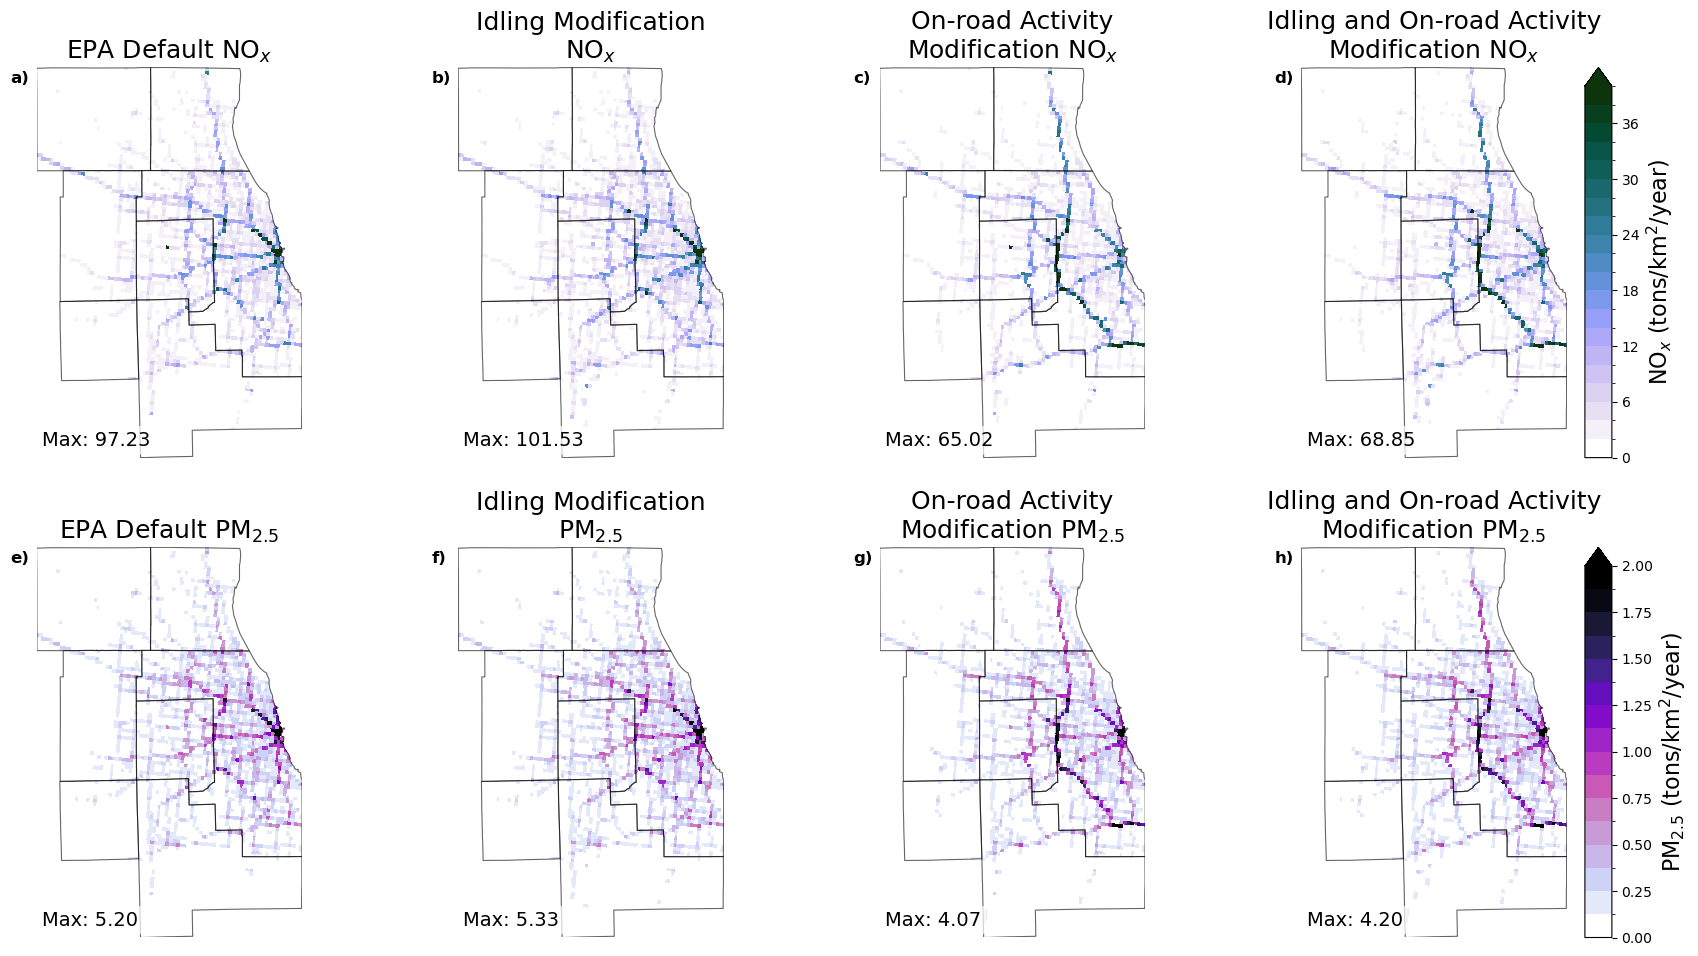

In [12]:
fig, axs = plt.subplots(
    nrows=2, ncols=4, figsize=(18, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# ============================================================
# NOx top row — original annual emissions
# ============================================================

_panel(
    axs[0,0], onroad_total_base_cmap, "NOX_peryear",
    cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX,
    "EPA Default NO$_x$", ann="max", label="a)"
)

_panel(
    axs[0,1], onroad_total_LOCUSIdling_cmap, "NOX_peryear",
    cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX,
    "Idling Modification\nNO$_x$", ann="max", label="b)"
)

_panel(
    axs[0,2], onroad_total_HDVSpatial_cmap, "NOX_peryear",
    cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX,
    "On-road Activity\nModification NO$_x$", ann="max", label="c)"
)

_panel(
    axs[0,3], onroad_total_LOCUSIdlingHDVSpatial_cmap, "NOX_peryear",
    cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX,
    "Idling and On-road Activity\nModification NO$_x$", ann="max", label="d)"
)


# ============================================================
# PM2.5 bottom row — original annual emissions
# ============================================================

_panel(
    axs[1,0], onroad_total_base_cmap, "PM25_peryear",
    cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX,
    "EPA Default PM$_{2.5}$", ann="max", label="e)"
)

_panel(
    axs[1,1], onroad_total_LOCUSIdling_cmap, "PM25_peryear",
    cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX,
    "Idling Modification\nPM$_{2.5}$", ann="max", label="f)"
)

_panel(
    axs[1,2], onroad_total_HDVSpatial_cmap, "PM25_peryear",
    cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX,
    "On-road Activity\nModification PM$_{2.5}$", ann="max", label="g)"
)

_panel(
    axs[1,3], onroad_total_LOCUSIdlingHDVSpatial_cmap, "PM25_peryear",
    cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX,
    "Idling and On-road Activity\nModification PM$_{2.5}$", ann="max", label="h)"
)


# ============================================================
# Layout
# ============================================================

fig.subplots_adjust(
    left=0.01,
    right=0.94,
    bottom=0.05,
    top=0.92,
    wspace=0.03,
    hspace=0.23,
)

# ============================================================
# Colorbars — one for NOx row and one for PM2.5 row
# ============================================================

pos_top = axs[0,3].get_position()
pos_bot = axs[1,3].get_position()

cax_nox = fig.add_axes([
    pos_top.x1 + 0.010,
    pos_top.y0,
    0.015,
    pos_top.height
])

cax_pm = fig.add_axes([
    pos_bot.x1 + 0.010,
    pos_bot.y0,
    0.015,
    pos_bot.height
])

cb_nox = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_abs_nox, cmap=cmap_abs_nox),
    cax=cax_nox,
    extend="max"
)
cb_nox.set_label("NO$_x$ (tons/km$^2$/year)", fontsize=16)

cb_pm = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_abs_pm, cmap=cmap_abs_pm),
    cax=cax_pm,
    extend="max"
)
cb_pm.set_label("PM$_{2.5}$ (tons/km$^2$/year)", fontsize=16)

plt.savefig("Fig_OriginalEmissionComparisons.pdf", dpi=300, bbox_inches="tight")
plt.show()

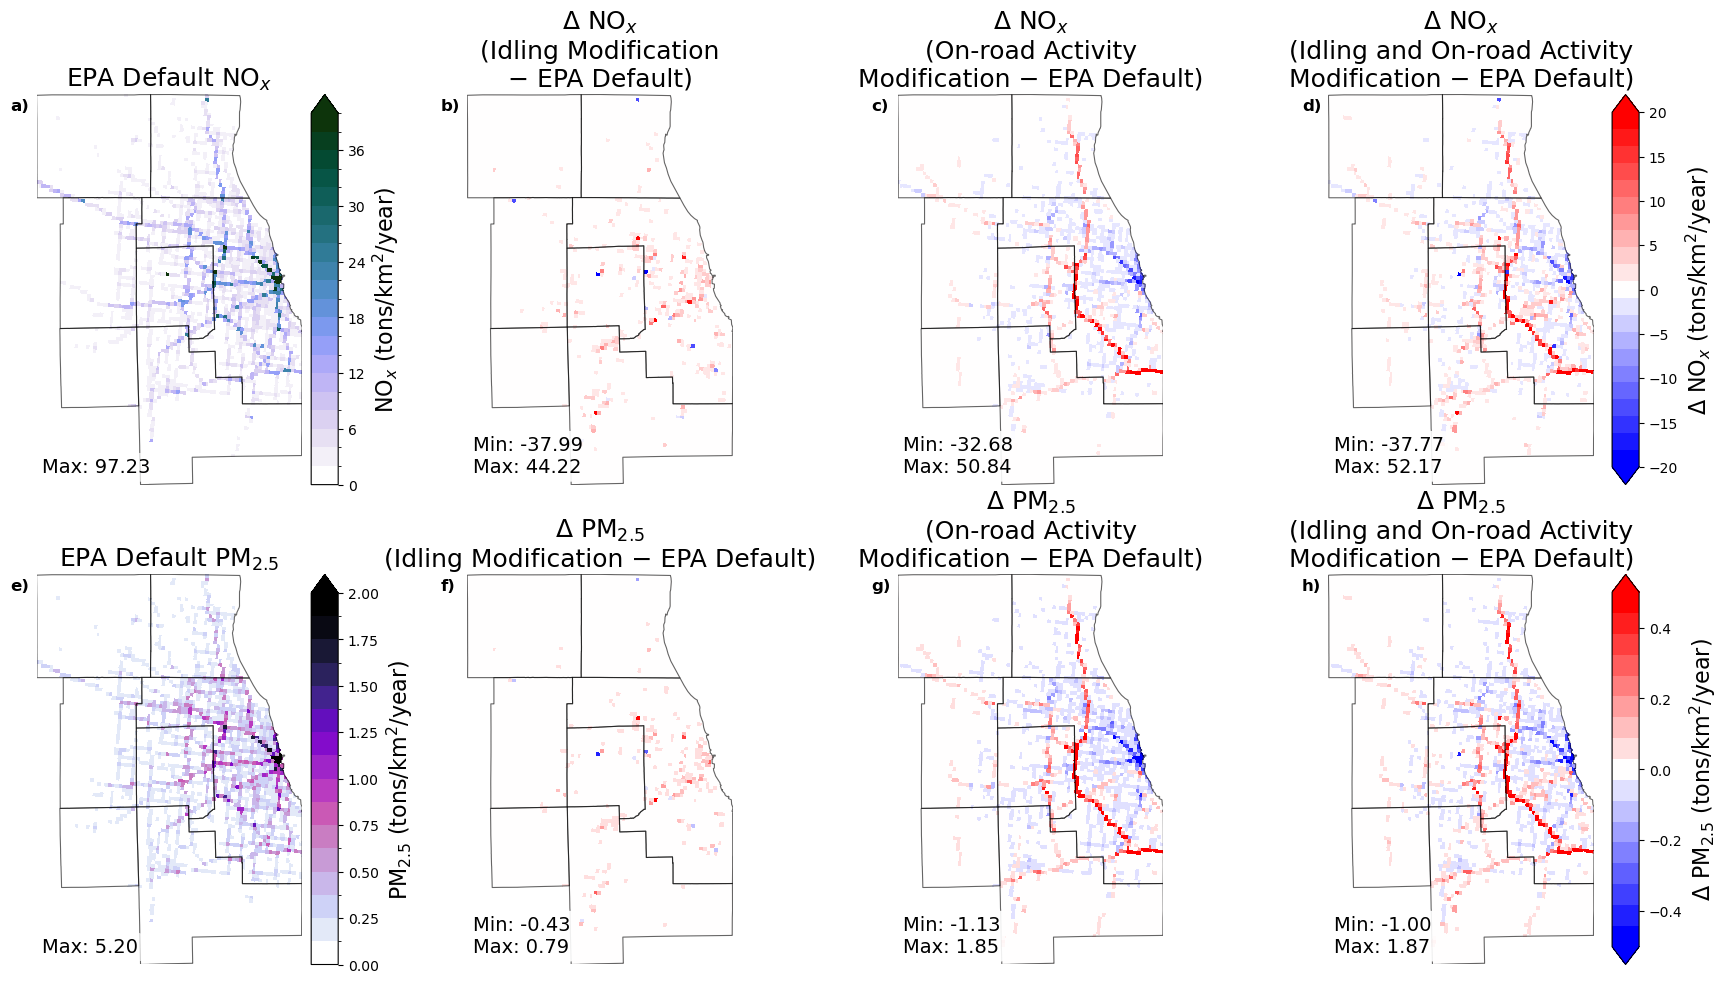

In [13]:
fig, axs = plt.subplots(
    nrows=2, ncols=4, figsize=(18, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

#NOx top row
_panel(axs[0,0], onroad_total_base_cmap, "NOX_peryear",
       cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX,
       "EPA Default NO$_x$", ann="max", label="a)")

_panel(axs[0,1], onroad_total_LOCUSIdling_cmap, "diff_nox",
       cmap_diff_nox, norm_diff_nox, NOX_DIFF_MIN, NOX_DIFF_MAX,
       "Δ NO$_x$\n(Idling Modification\n− EPA Default)", label="b)")

_panel(axs[0,2], onroad_total_HDVSpatial_cmap, "diff_nox",
       cmap_diff_nox, norm_diff_nox, NOX_DIFF_MIN, NOX_DIFF_MAX,
       "Δ NO$_x$\n(On-road Activity\nModification − EPA Default)", label="c)")

_panel(axs[0,3], onroad_total_LOCUSIdlingHDVSpatial_cmap, "diff_nox",
       cmap_diff_nox, norm_diff_nox, NOX_DIFF_MIN, NOX_DIFF_MAX,
       "Δ NO$_x$\n(Idling and On-road Activity\nModification − EPA Default)", label="d)")

#PM2.5 bottom row
_panel(axs[1,0], onroad_total_base_cmap, "PM25_peryear",
       cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX,
       "EPA Default PM$_{2.5}$", ann="max", label="e)")

_panel(axs[1,1], onroad_total_LOCUSIdling_cmap, "diff_pm25",
       cmap_diff_pm, norm_diff_pm, PM25_DIFF_MIN, PM25_DIFF_MAX,
       "Δ PM$_{2.5}$\n(Idling Modification − EPA Default)", label="f)")

_panel(axs[1,2], onroad_total_HDVSpatial_cmap, "diff_pm25",
       cmap_diff_pm, norm_diff_pm, PM25_DIFF_MIN, PM25_DIFF_MAX,
       "Δ PM$_{2.5}$\n(On-road Activity\nModification − EPA Default)", label="g)")

_panel(axs[1,3], onroad_total_LOCUSIdlingHDVSpatial_cmap, "diff_pm25",
       cmap_diff_pm, norm_diff_pm, PM25_DIFF_MIN, PM25_DIFF_MAX,
       "Δ PM$_{2.5}$\n(Idling and On-road Activity\nModification − EPA Default)", label="h)")

# 
#plt.tight_layout()
#fig.subplots_adjust(wspace=0.06, hspace=0.08)
fig.subplots_adjust(
    left=0.01,
    right=0.96,
    bottom=0.05,
    top=0.92,
    wspace=0.03,
    hspace=0.23,
)

pos_col1_top = axs[0,0].get_position()
pos_col1_bot = axs[1,0].get_position()

pos_col4_top = axs[0,3].get_position()
pos_col4_bot = axs[1,3].get_position()
cax_abs_nox = fig.add_axes([
    pos_col1_top.x1 + 0.005,  # just right of column 1
    pos_col1_top.y0,
    0.015,
    pos_col1_top.height
])

cax_abs_pm = fig.add_axes([
    pos_col1_bot.x1 + 0.005,
    pos_col1_bot.y0,
    0.015,
    pos_col1_bot.height
])

# Difference colorbars — aligned with columns 2–4
cax_diff_nox = fig.add_axes([
    pos_col4_top.x1 + 0.010,  # right of column 4
    pos_col4_top.y0,
    0.015,
    pos_col4_top.height
])

cax_diff_pm = fig.add_axes([
    pos_col4_bot.x1 + 0.010,
    pos_col4_bot.y0,
    0.015,
    pos_col4_bot.height
])

# --------------------------------------------------
# Draw colorbars
# --------------------------------------------------
cb1 = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_abs_nox, cmap=cmap_abs_nox),
    cax=cax_abs_nox, extend="max"
)
cb1.set_label("NO$_x$ (tons/km$^2$/year)", fontsize=16)

cb1d = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_diff_nox, cmap=cmap_diff_nox),
    cax=cax_diff_nox, extend="both"
)
cb1d.set_label("Δ NO$_x$ (tons/km$^2$/year)", fontsize=16)

cb2 = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_abs_pm, cmap=cmap_abs_pm),
    cax=cax_abs_pm, extend="max"
)
cb2.set_label("PM$_{2.5}$ (tons/km$^2$/year)", fontsize=16)

cb2d = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_diff_pm, cmap=cmap_diff_pm),
    cax=cax_diff_pm, extend="both"
)
cb2d.set_label("Δ PM$_{2.5}$ (tons/km$^2$/year)", fontsize=16)

plt.savefig("Fig_EmissionComparisons.png")
plt.show()